改进版本的crystalnn

In [1]:
from define_structural_primitives import (
get_crystalnn_motifs_adaptive,
identify_asymmetric_unit
)


In [2]:
import os
import glob
import traceback
from pymatgen.core import Structure, Element
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

In [3]:
def format_motif_output(filename, motifs):
    """生成你要求的文本格式 (修复 Key Error 版)"""
    output_lines = []
    output_lines.append(f"--- Processing: {filename} ---")
    
    for i, m in enumerate(motifs):
        # 准备数据
        species = "".join([c for c in m['central_atom']['species'] if c.isalpha()]) 
        wyckoff = m['central_atom']['wyckoff']
        cn = m['coordination_number']
        
        # 【修复点在这里】
        # 优先读取 'coordination_environment'，如果找不到再试 'environment'，还不行就显示 'Unknown'
        env = m.get('coordination_environment', m.get('environment', 'Unknown'))
        
        # 读取 RMS，如果找不到（比如旧版函数没算 RMS），就默认为 0
        rms = m.get('rms_angle_deviation', m.get('rms', 0.0))
        
        distorted_str = "(distorted)" if m.get('distorted', False) else ""
        
        # 兼容 neighbor_counts 可能不存在的情况（旧版代码可能没统计这个）
        if 'neighbor_counts' in m:
            counts = m['neighbor_counts']
            neighbors_list = m['neighbor_details']
        else:
            # 如果是旧版代码，现场统计一下，防止报错
            counts = {}
            neighbors_list = []
            for nb in m['neighbors']:
                s = "".join([c for c in nb['species'] if c.isalpha()])
                counts[s] = counts.get(s, 0) + 1
                neighbors_list.append((s, nb['index']))

        idx = m['central_atom']['index']

        # 格式化第一行
        line1 = (f"Motif {i+1}: {species} ({wyckoff}) CN={cn} - {env} "
                 f"RMS={rms:.3f}° {distorted_str} | Neighbors count: {counts}")
        
        # 格式化第二行
        line2 = f"  Neighbor species & indices: {neighbors_list}"
        
        # 格式化第三行
        line3 = f"  Central atom index: {idx}"
        
        output_lines.append(line1)
        output_lines.append(line2)
        output_lines.append(line3)
        output_lines.append("") 
        
    return "\n".join(output_lines)
def process_cif_directory(directory_path, output_file="extracted_motifs_report.txt"):
    cif_files = glob.glob(os.path.join(directory_path, "*.cif"))
    print(f"Found {len(cif_files)} CIF files in {directory_path}")
    
    with open(output_file, "w", encoding='utf-8') as f:
        for cif_file in cif_files:
            try:
                # 1. 读取结构
                structure = Structure.from_file(cif_file)
                
                # 2. 对称性分析 (获取 Wyckoff)
                sga = SpacegroupAnalyzer(structure, symprec=0.01)
                symmetrized_structure = sga.get_symmetrized_structure()
                
                # 3. 提取基元
                motifs = get_crystalnn_motifs_adaptive(structure, symmetrized_structure)
                
                # 4. 格式化并写入
                filename = os.path.basename(cif_file)
                report_text = format_motif_output(filename, motifs)
                
                f.write(report_text + "\n" + "="*50 + "\n")
                print(f"Processed: {filename}")
                
            except Exception as e:
                error_msg = f"Error processing {cif_file}: {str(e)}\n{traceback.format_exc()}"
                print(error_msg)
                f.write(f"!!! Error processing {os.path.basename(cif_file)} !!!\n")
                f.write(str(e) + "\n\n")

# ==========================================
# 4. 执行入口
# ==========================================

if __name__ == "__main__":
    # 指定你的路径
    target_dir = "/home/gaotianjiao/modnet-master/ext_struc/spinels_cif"
    output_path = "spinels_motifs_report.txt"
    
    # 检查路径是否存在
    if os.path.exists(target_dir):
        process_cif_directory(target_dir, output_path)
        print(f"\nDone! Results saved to {output_path}")
    else:
        print(f"Error: Directory not found: {target_dir}")

Found 329 CIF files in /home/gaotianjiao/modnet-master/ext_struc/spinels_cif
Processed: mp-1201604.cif
Processed: mp-14246.cif
Processed: mp-30958.cif
Processed: mp-849286.cif
Processed: mp-774941.cif
Processed: mp-773076.cif
Processed: mvc-14772.cif
Processed: mp-1222624.cif
Processed: mp-2221507.cif
Processed: mp-1246286.cif
Processed: mp-1388111.cif
Processed: mp-1389421.cif
Processed: mp-1247073.cif
Processed: mp-1238859.cif
Processed: mp-1238886.cif
Processed: mp-1247104.cif
Processed: mp-1238779.cif
Processed: mp-1232170.cif
Processed: mp-1238827.cif
Processed: mp-1238805.cif
Processed: mp-1232294.cif
Processed: mp-1232096.cif
Processed: mp-1400406.cif
Processed: mp-1232131.cif
Processed: mp-1232270.cif
Processed: mp-1247043.cif
Processed: mp-1394188.cif
Processed: mp-1390164.cif
Processed: mp-1395289.cif
Processed: mp-1443364.cif
Processed: mp-14307.cif
Processed: mp-1443666.cif
Processed: mp-1446454.cif
Processed: mp-14305.cif
Processed: mp-1410970.cif
Processed: mp-1408976.cif

spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.


Processed: mp-22584.cif
Processed: mp-754234.cif
Processed: mp-754168.cif
Processed: mp-754114.cif
Processed: mp-753991.cif
Processed: mp-753983.cif
Processed: mp-753815.cif
Processed: mp-754077.cif
Processed: mp-754491.cif
Processed: mp-752679.cif
Processed: mp-754093.cif
Processed: mp-753418.cif
Processed: mp-752643.cif
Processed: mp-753489.cif
Processed: mp-753397.cif
Processed: mp-753222.cif
Processed: mp-688785.cif
Processed: mp-754069.cif
Processed: mp-640147.cif
Processed: mp-754942.cif
Processed: mp-754211.cif
Processed: mp-760340.cif
Processed: mp-758452.cif
Processed: mp-756646.cif
Processed: mp-753385.cif
Processed: mp-756338.cif
Processed: mp-756271.cif
Processed: mp-756297.cif
Processed: mp-754240.cif


/home/gaotianjiao/anaconda3/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


Processed: mp-756442.cif
Processed: mp-755558.cif
Processed: mp-756229.cif
Processed: mp-755634.cif
Processed: mp-755239.cif
Processed: mp-755611.cif
Processed: mp-755044.cif
Processed: mp-754557.cif
Processed: mp-755882.cif
Processed: mp-608016.cif
Processed: mp-5794.cif
Processed: mp-5670.cif
Processed: mp-3319.cif
Processed: mp-30545.cif
Processed: mp-29399.cif
Processed: mp-30084.cif
Processed: mp-2908.cif
Processed: mp-25387.cif
Processed: mp-28226.cif
Processed: mp-3443.cif
Processed: mp-25385.cif
Processed: mp-25388.cif
Processed: mp-25383.cif
Processed: mp-22684.cif
Processed: mp-25386.cif
Processed: mp-22766.cif
Processed: mp-27719.cif
Processed: mp-22638.cif
Processed: mp-27872.cif
Processed: mp-34146.cif
Processed: mp-3536.cif
Processed: mp-35475.cif
Processed: mp-5639.cif
Processed: mp-561097.cif
Processed: mp-558096.cif
Processed: mp-560842.cif
Processed: mp-554354.cif
Processed: mp-546936.cif
Processed: mp-5146.cif
Processed: mp-505421.cif
Processed: mp-505623.cif
Process

正在读取文件: /home/gaotianjiao/modnet-master/ext_struc/spinels_motifs_report.txt ...
✅ 数据准备就绪，共 2997 个数据点。正在绘图...


/tmp/ipykernel_63215/2978998195.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ 图片已保存为: geometric_screening_proof.png


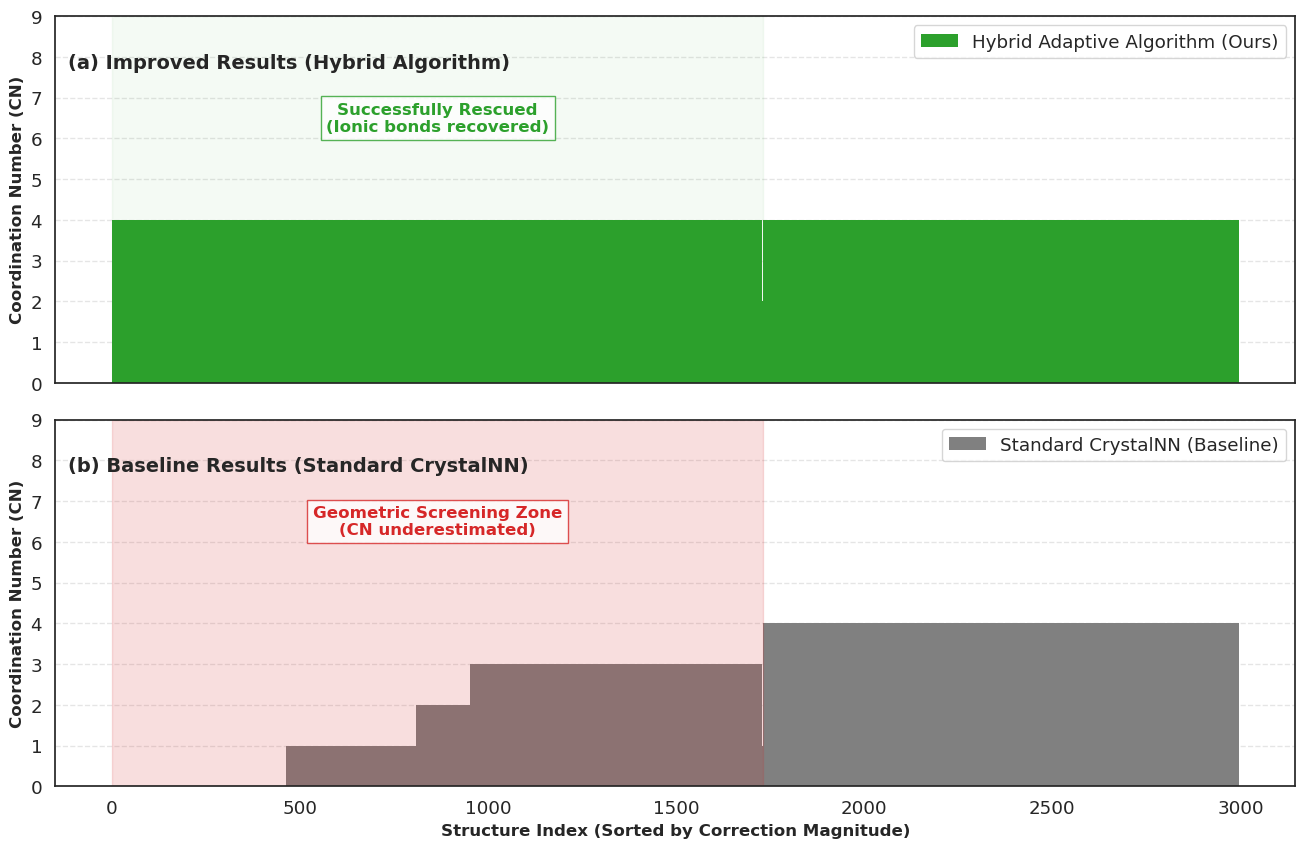

In [4]:
import re
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================= 配置参数 =================
INPUT_FILE = "/home/gaotianjiao/modnet-master/ext_struc/spinels_motifs_report.txt"
OUTPUT_IMAGE = "geometric_screening_proof.png"

# 定义标准算法通常能看到的"短程/共价"金属 (B位阳离子)
# 这些元素形成的键较短，不易被 Voronoi 几何遮蔽
VISIBLE_IN_STANDARD = [
    'Al', 'Ga', 'In', 'Tl',
    'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
    'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd',
    'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',
    'Si', 'Ge', 'Sn', 'Pb', 'Sb', 'Bi', 'As', 'P'
]

# 定义容易被遮蔽的"长程/离子"金属 (A位阳离子)
# 这些元素半径大，键长长，在 Voronoi 划分中容易被短键遮挡权重归零
SCREENED_IN_STANDARD = [
    'Li', 'Na', 'K', 'Rb', 'Cs',
    'Mg', 'Ca', 'Sr', 'Ba',
    'Sc', 'Y', 'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'
]

def parse_and_plot_evidence():
    data = []
    print(f"正在读取文件: {INPUT_FILE} ...")
    
    # 1. 读取并解析数据
    try:
        with open(INPUT_FILE, "r", encoding="utf-8") as f:
            current_filename = "Unknown"
            for line in f:
                line = line.strip()
                if "Processing:" in line:
                    current_filename = line.split("Processing:")[1].strip().replace(".cif", "")
                    continue
                
                # 解析 Motif 行
                if line.startswith("Motif") and "Neighbors count:" in line:
                    try:
                        info_part, neighbors_part = line.split("|")
                        
                        # 提取中心元素
                        element_match = re.search(r"Motif \d+: ([A-Za-z]+)", info_part)
                        if not element_match: continue
                        element = element_match.group(1)
                        
                        # 只关注阴离子 (S, Se, Te, O, F, Cl, Br, I)
                        if element not in ['S', 'Se', 'Te', 'O', 'F', 'Cl', 'Br', 'I']: 
                            continue 
                        
                        # 提取改进后的 CN (New)
                        cn_match = re.search(r"CN=(\d+)", info_part)
                        cn_new = int(cn_match.group(1)) if cn_match else 0
                        
                        # 提取邻居字典
                        dict_str = neighbors_part.split("Neighbors count:")[1].strip()
                        neighbors = ast.literal_eval(dict_str)
                        
                        # 模拟标准算法 CN (Std)
                        cn_std = 0
                        for neigh_elem, count in neighbors.items():
                            # 逻辑：如果邻居在 VISIBLE 列表中，标准算法能看到
                            if neigh_elem in VISIBLE_IN_STANDARD:
                                cn_std += count
                            # 如果邻居既不在 VISIBLE 也不在 SCREENED (比如稀有情况)，暂且认为能看到
                            elif neigh_elem not in SCREENED_IN_STANDARD:
                                cn_std += count
                        
                        # 计算差异
                        diff = cn_new - cn_std
                        
                        data.append({
                            "Structure": current_filename,
                            "Element": element,
                            "CN_New": cn_new,
                            "CN_Std": cn_std,
                            "Diff": diff
                        })
                    except Exception as e:
                        continue
    except FileNotFoundError:
        print(f"❌ 错误: 找不到文件 {INPUT_FILE}")
        return

    df = pd.DataFrame(data)
    
    if df.empty:
        print("❌ 未提取到有效数据，请检查 txt 文件格式。")
        return

    # 2. 数据处理与排序
    # 排序逻辑：
    # (1) Diff 降序（把被修复的放在最左边，形成鲜明对比）
    # (2) CN_New 降序
    # (3) CN_Std 升序
    df_plot = df.sort_values(by=['Diff', 'CN_New', 'CN_Std'], ascending=[False, False, True]).reset_index(drop=True)

    print(f"✅ 数据准备就绪，共 {len(df_plot)} 个数据点。正在绘图...")

    # 3. 绘图：上下分图 (Subplots)
    sns.set(style="white", font_scale=1.2)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'hspace': 0.1})
    
    x = range(len(df_plot))

    # --- 上图：改进算法 (Hybrid Algorithm) ---
    # 使用绿色表示"正确/修复后"
    ax1.bar(x, df_plot['CN_New'], color='#2ca02c', width=1.0, edgecolor='none', label='Hybrid Adaptive Algorithm (Ours)')
    ax1.set_ylabel('Coordination Number (CN)', fontweight='bold', fontsize=12)
    ax1.set_ylim(0, 9)
    ax1.set_yticks(range(0, 10))
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 添加图例和标题
    ax1.legend(loc='upper right', frameon=True)
    ax1.text(0.01, 0.9, '(a) Improved Results (Hybrid Algorithm)', transform=ax1.transAxes, 
             fontsize=14, fontweight='bold', va='top')

    # --- 下图：标准算法 (Standard Algorithm - Simulated) ---
    # 使用灰色表示"基准/有缺陷"
    ax2.bar(x, df_plot['CN_Std'], color='gray', width=1.0, edgecolor='none', label='Standard CrystalNN (Baseline)')
    ax2.set_ylabel('Coordination Number (CN)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Structure Index (Sorted by Correction Magnitude)', fontweight='bold', fontsize=12)
    ax2.set_ylim(0, 9)
    ax2.set_yticks(range(0, 10))
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    
    # 添加图例
    ax2.legend(loc='upper right', frameon=True)
    ax2.text(0.01, 0.9, '(b) Baseline Results (Standard CrystalNN)', transform=ax2.transAxes, 
             fontsize=14, fontweight='bold', va='top')

    # --- 4. 添加高亮区域证明“几何遮蔽被解决” ---
    # 计算有多少个结构被修复了 (Diff > 0)
    n_rescued = len(df_plot[df_plot['Diff'] > 0])
    
    if n_rescued > 0:
        # 在下图（标准算法）中，用红色阴影标记出"缺失的部分"
        ax2.axvspan(0, n_rescued, color='#d62728', alpha=0.15)
        
        # 添加文字注释
        # 在下图中标注"几何遮蔽区"
        ax2.text(n_rescued / 2, 6.5, f"Geometric Screening Zone\n(CN underestimated)", 
                 ha='center', va='center', color='#d62728', fontweight='bold', fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='#d62728'))
        
        # 在上图中标注"修复成功"
        ax1.axvspan(0, n_rescued, color='#2ca02c', alpha=0.05)
        ax1.text(n_rescued / 2, 6.5, f"Successfully Rescued\n(Ionic bonds recovered)", 
                 ha='center', va='center', color='#2ca02c', fontweight='bold', fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='#2ca02c'))

    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE, dpi=300)
    print(f"✅ 图片已保存为: {OUTPUT_IMAGE}")
    plt.show()

if __name__ == "__main__":
    parse_and_plot_evidence()

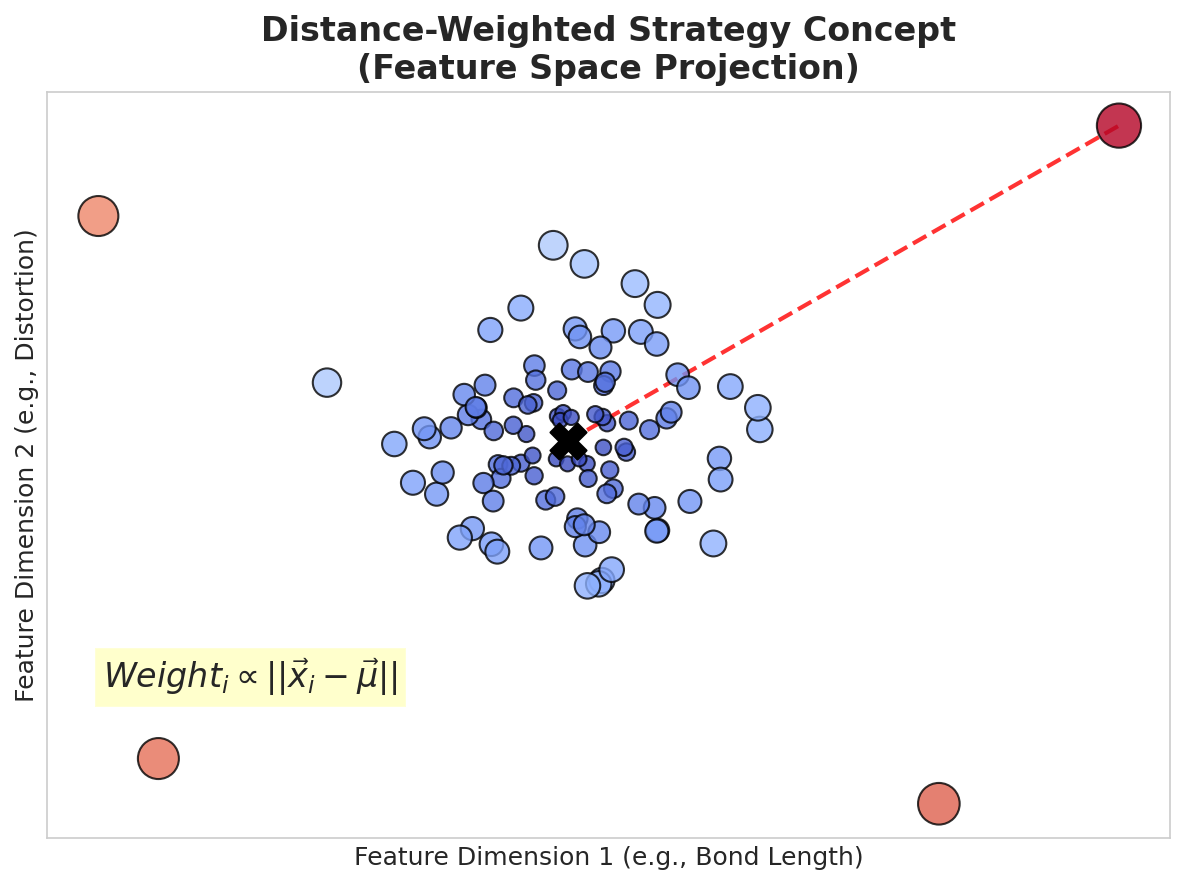

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def draw_distance_weighting_concept():
    # 设置随机种子
    np.random.seed(42)
    n_normal = 100
    normal_points = np.random.normal(loc=0, scale=0.8, size=(n_normal, 2))
    
    # B. "异常"原子 (Outliers/Defects): 远离中心，数量少
    outliers = np.array([
        [4.5, 3.5],   # 表面原子
        [-4.0, 2.5],  # 掺杂原子
        [3.0, -4.0],  # 空位附近
        [-3.5, -3.5]  # 晶界原子
    ])
    
    # 合并数据
    all_points = np.vstack([normal_points, outliers])
    
    # 2. 计算几何中心 (Centroid)
    centroid = np.mean(all_points, axis=0)
    
    # 3. 计算每个点到中心的距离 (作为权重)
    distances = np.linalg.norm(all_points - centroid, axis=1)
    
    # 归一化距离用于绘图大小和颜色 (让效果更夸张一点)
    norm_distances = (distances - distances.min()) / (distances.max() - distances.min())
    sizes = 50 + norm_distances * 400  # 距离越远，点越大 (50 -> 450)
    
    # ==========================================
    # 绘图
    # ==========================================
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    
    # 画背景网格
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 1. 画所有原子点 (根据距离变色、变大)
    scatter = ax.scatter(all_points[:, 0], all_points[:, 1], 
                         s=sizes, c=distances, cmap='coolwarm', 
                         alpha=0.8, edgecolors='k', zorder=10)
    
    # 2. 画几何中心 (The "Average")
    ax.scatter(centroid[0], centroid[1], s=300, marker='X', c='black', zorder=20, label='Average Vector (Centroid)')
    
    # 3. 画连接线 (表现 "Euclidean Distance")
    # 只画几个典型的连接线，避免太乱
    # 画一个近的 (Low Weight)
    idx_close = np.argmin(distances)
    p_close = all_points[idx_close]
    ax.plot([centroid[0], p_close[0]], [centroid[1], p_close[1]], 'k:', alpha=0.5)
    ax.text((centroid[0]+p_close[0])/2, (centroid[1]+p_close[1])/2, ' ', fontsize=10)
    
    # 画一个远的 (High Weight)
    idx_far = np.argmax(distances)
    p_far = all_points[idx_far]
    ax.plot([centroid[0], p_far[0]], [centroid[1], p_far[1]], 'r--', lw=2, alpha=0.8)
    ax.text((centroid[0]+p_far[0])/2 - 0.5, (centroid[1]+p_far[1])/2 + 0.5, ' ', 
            color='red', fontsize=12, fontweight='bold')

    # 4. 添加注释 (Annotations)
    # 注释中心
    ax.annotate(' ', 
                xy=(0.5, 0.5), xytext=(-3, 1),
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2"),
                fontsize=11, color='navy')
    '''
    # 注释离群点
    ax.annotate('Defect/Surface Site\n(High Weight!)', 
                xy=(outliers[0][0], outliers[0][1]), xytext=(5, 5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=12, fontweight='bold', color='darkred',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
    '''
    # 5. 装饰
    ax.set_title("Distance-Weighted Strategy Concept\n(Feature Space Projection)", fontsize=16, fontweight='bold')
    ax.set_xlabel("Feature Dimension 1 (e.g., Bond Length)", fontsize=12)
    ax.set_ylabel("Feature Dimension 2 (e.g., Distortion)", fontsize=12)
    
    # 隐藏刻度数字，只保留概念
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 添加公式
    plt.text(0.05, 0.2, r"$Weight_i \propto || \vec{x}_i - \vec{\mu} ||$", 
             transform=ax.transAxes, fontsize=16, 
             bbox=dict(facecolor='yellow', alpha=0.2))

    plt.tight_layout()
    plt.show()

draw_distance_weighting_concept()

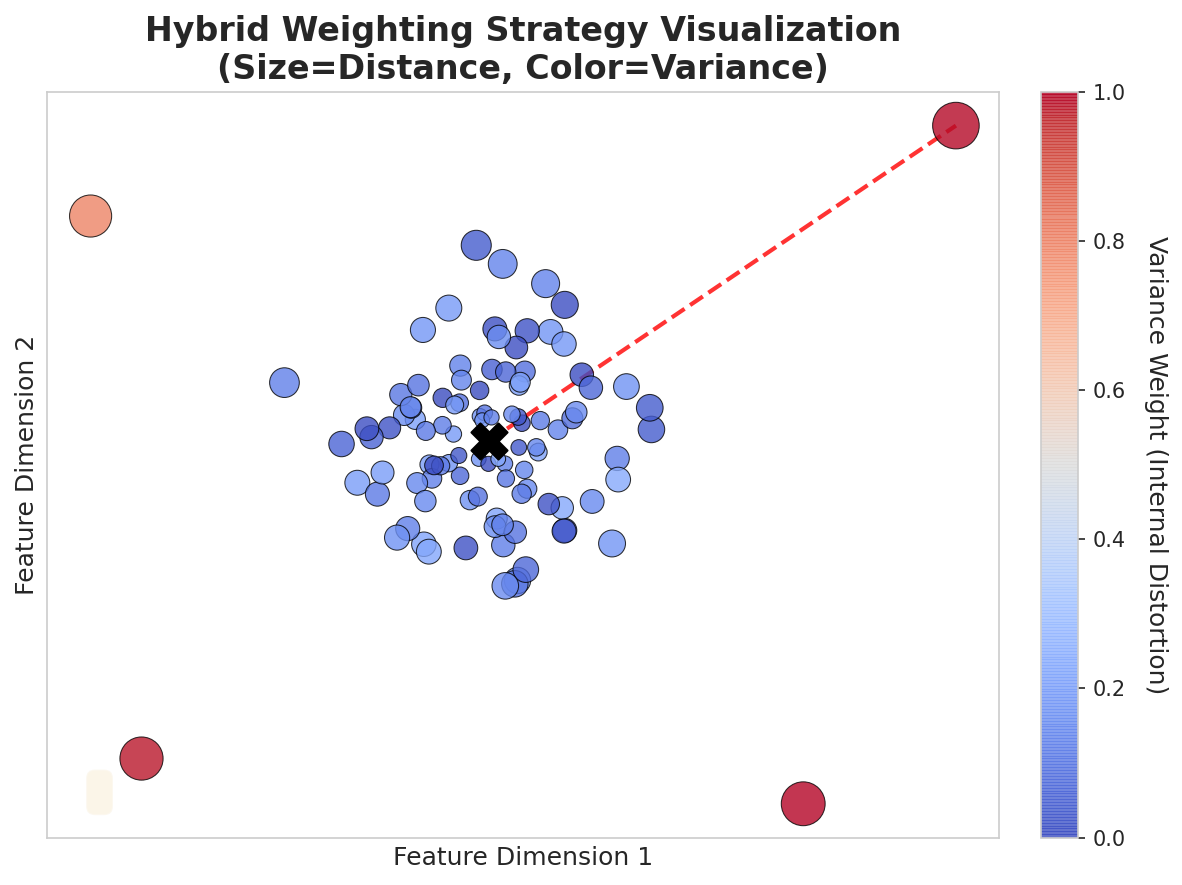

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def draw_dual_weighted_concept_with_colorbar():
    # 设置随机种子
    np.random.seed(42)
    
    # ==========================================
    # 1. 数据生成与模拟
    # ==========================================
    # A. "平凡"原子 (Normal Atoms): 聚集在中心
    n_normal = 100
    normal_points = np.random.normal(loc=0, scale=0.8, size=(n_normal, 2))
    # 模拟：平凡原子的方差较小 (稳定)
    var_normal = np.random.uniform(0.1, 1.5, size=n_normal)
    
    # B. "异常"原子 (Outliers/Defects): 远离中心
    outliers = np.array([
        [4.5, 3.5],   # 表面原子
        [-4.0, 2.5],  # 掺杂原子
        [3.0, -4.0],  # 空位附近
        [-3.5, -3.5]  # 晶界原子
    ])
    # 模拟：异常原子的方差较大 (畸变严重)
    var_outliers = np.random.uniform(4.0, 6.0, size=len(outliers))
    
    # C. 合并数据
    all_points = np.vstack([normal_points, outliers])
    all_variances = np.concatenate([var_normal, var_outliers])
    
    # ==========================================
    # 2. 特征计算 (距离 & 方差)
    # ==========================================
    # 计算几何中心 (Centroid)
    centroid = np.mean(all_points, axis=0)
    
    # 计算每个点到中心的距离 (决定点的大小)
    distances = np.linalg.norm(all_points - centroid, axis=1)
    norm_distances = (distances - distances.min()) / (distances.max() - distances.min())
    sizes = 50 + norm_distances * 450  # 距离越远，点越大
    
    # 归一化方差 (决定颜色的深浅)
    norm_variances = (all_variances - all_variances.min()) / (all_variances.max() - all_variances.min())

    # ==========================================
    # 3. 绘图
    # ==========================================
    fig, ax = plt.subplots(figsize=(8,6), dpi=150) #稍微加宽画布以容纳colorbar
    
    # 画背景网格
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # --- 核心散点图 ---
    # s=sizes: 大小代表距离中心远近 (Distance Weight)
    # c=norm_variances: 颜色深浅代表方差大小 (Variance Weight)
    # cmap='Reds': 使用红色系，颜色越深代表值越大
    sc = ax.scatter(all_points[:, 0], all_points[:, 1], 
                    s=sizes, 
                    c=norm_variances, cmap='coolwarm', vmin=0, vmax=1,
                    alpha=0.8, edgecolors='k', linewidth=0.5, zorder=10)
    
    # 画几何中心 (The "Average")
    ax.scatter(centroid[0], centroid[1], s=300, marker='X', c='black', zorder=20, label='Average Vector (Centroid)')
    
    # --- 添加连接线和注释 ---
    # 画一个近的 (Low Distance)
    idx_close = np.argmin(distances)
    p_close = all_points[idx_close]
    ax.plot([centroid[0], p_close[0]], [centroid[1], p_close[1]], 'k:', alpha=0.5)
    
    # 画一个远的 (High Distance)
    idx_far = np.argmax(distances)
    p_far = all_points[idx_far]
    ax.plot([centroid[0], p_far[0]], [centroid[1], p_far[1]], 'r--', lw=2, alpha=0.8)

    # 添加图例解释双重含义
    ax.text(0.03, 0.92, " ", transform=ax.transAxes, fontsize=10, fontweight='bold', color='navy')
    ax.text(0.03, 0.87, " ", transform=ax.transAxes, fontsize=10, fontweight='bold', color='darkred')

    # --- 添加颜色条 (Colorbar) ---
    # fraction: colorbar 占用的比例, pad: 与图的间距
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    # 设置颜色条的标签
    cbar.set_label('Variance Weight (Internal Distortion)', fontsize=12, rotation=270, labelpad=20)
    
    # 装饰
    ax.set_title("Hybrid Weighting Strategy Visualization\n(Size=Distance, Color=Variance)", fontsize=16, fontweight='bold')
    ax.set_xlabel("Feature Dimension 1", fontsize=12)
    ax.set_ylabel("Feature Dimension 2", fontsize=12)
    
    # 隐藏刻度数字
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 添加综合公式注释
    plt.text(0.05, 0.05, r" ", 
             transform=ax.transAxes, fontsize=14, 
             bbox=dict(facecolor='wheat', alpha=0.3, boxstyle='round'))

    plt.tight_layout()
    plt.show()

draw_dual_weighted_concept_with_colorbar()

In [2]:

from mp_api.client import MPRester

def download_structure(material_id, api_key):
    print(f"正在连接 Materials Project 下载 {material_id} ...")
    
    try:

        with MPRester(api_key) as mpr:
            # 获取结构
            structure = mpr.get_structure_by_material_id(material_id)
            
            print("\n下载成功！结构信息如下：")
            print(structure)
            
            # 保存为 CIF 文件
            filename = f"{material_id}_CaSnO3_corrected.cif"
            structure.to(filename=filename)
            print(f"\n已保存为文件: {filename}")
            
            return structure
            
    except Exception as e:
        print(f"❌ 下载失败: {e}")
        print("提示: 请检查你的 API Key 是否正确，或网络是否通畅。")
        return None


YOUR_API_KEY = "7PYF7c0DvFXufDMo1DL6yLZQbv7ZMpNp" 

if __name__ == "__main__":
    # 下载 mp-546910 (CaSnO3)
    struct = download_structure("mp-546910", YOUR_API_KEY)
    
    # 简单的验证：打印一下 Ca 和 Sn 的坐标，看看是否正常
    if struct:
        print("\n--- 快速检查阳离子位置 ---")
        for site in struct:
            if site.specie.symbol in ["Ca", "Sn"]:
                print(f"{site.specie}: {site.frac_coords}")

正在连接 Materials Project 下载 mp-546910 ...


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]


下载成功！结构信息如下：
Full Formula (Ca1 Sn1 O3)
Reduced Formula: CaSnO3
abc   :   4.349933   4.349933   4.349933
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (5)
  #  SP      a    b    c    magmom
---  ----  ---  ---  ---  --------
  0  Ca    0.5  0.5  0.5    -0.014
  1  Sn    0    0    0       0.034
  2  O     0    0.5  0.5    -0.578
  3  O     0.5  0.5  0      -0.578
  4  O     0.5  0    0.5    -0.578

已保存为文件: mp-546910_CaSnO3_corrected.cif

--- 快速检查阳离子位置 ---
Ca: [0.5 0.5 0.5]
Sn: [0. 0. 0.]
